# Parameter Estimation via HYPAGS

*Aaron Peche & Martin Vonk (2026)*

## Overview

HYPAGS (HYdraulic Parameters And Grain Sizes) is a parameter estimation method that can estimate full van Genuchten soil hydraulic parameters from minimal input data:
- **A single saturated conductivity value (k)** or **representative grain diameters (d10/d20)**

This is useful when:
- You have measured soil conductivity but no water retention curve
- You only have grain size information from grain size analysis
- You need a quick estimate but lack the data for pedotransfer functions

Peche, A., Houben, G. and Altfelder, S. (2024), Approximation of van Genuchten Parameter Ranges from Hydraulic Conductivity Data. Groundwater, 62: 469-479. https://doi.org/10.1111/gwat.13365

In [1]:
import pedon as pe

## Inputs Available for HYPAGS

HYPAGS can work with different types of input data. The method will use whichever measurement is provided. 

The accuracy depends on the input type. Conductivity measurements are generally more reliable because they directly affect water movement, while grain size is an indirect proxy.

## Example 1: Estimate from Saturated Conductivity

In [2]:
# Estimate from saturated conductivity
# Note: HYPAGS expects k in m/s
k_value = 1e-5  # m/s
ss_k = pe.SoilSample(k=k_value)
hyp_k = ss_k.hypags()

print("Estimated van Genuchten parameters from k value:")
print(hyp_k)

Estimated van Genuchten parameters from k value:
Genuchten(k_s=1e-05, theta_r=0.108, theta_s=np.float64(0.2583863334264952), alpha=np.float64(3.0954271061989362), n=np.float64(1.7620036659998843), l=0.5)


## Example 2: Estimate from the Representative D10 Grain Diameter

In [3]:
# Estimate from grain diameter
# d10: 10th percentile diameter
d10_value = 1e-5  # m
ss_d10 = pe.SoilSample(d10=d10_value)
hyp_d10 = ss_d10.hypags()

print("Estimated van Genuchten parameters from d10:")
print(hyp_d10)

d10 (1.000e-05) out of hypags model limits: 5.35e-5 to 8.3e-4.


Estimated van Genuchten parameters from d10:
Genuchten(k_s=7.806785158323015e-07, theta_r=0.099, theta_s=np.float64(0.22816361767085197), alpha=np.float64(1.0847731683725947), n=np.float64(1.7288852832248782), l=0.5)


## Comparing Results

Let's visualize how estimates from different inputs compare.

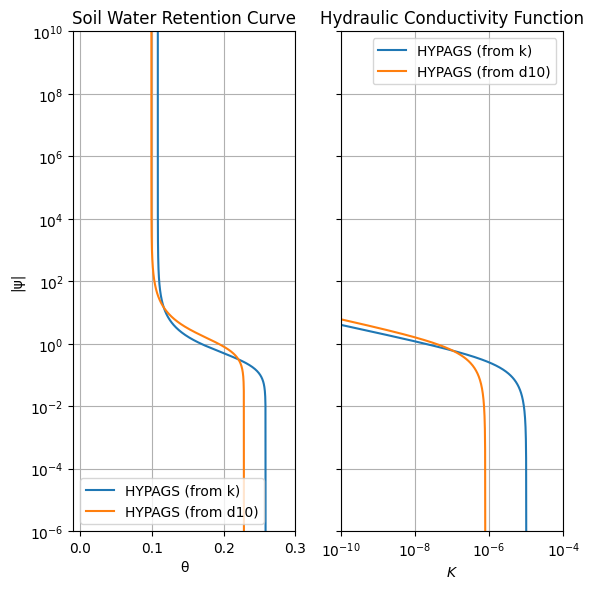

In [4]:
axes = pe.plot.curves(hyp_k, label="HYPAGS (from k)")
pe.plot.curves(hyp_d10, axes, label="HYPAGS (from d10)")
axes[0].set_title("Soil Water Retention Curve")
axes[0].set_xlim(-0.01, 0.3)
axes[0].legend()

axes[1].set_title("Hydraulic Conductivity Function")
axes[1].set_xlim(1e-10, 1e-4)
axes[1].set_ylabel("")
axes[1].legend()